# Data Loading & Date Parsing

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load Data

In [4]:
df = pd.read_csv("../data/nigeria.csv")  # replace with your file
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## Add Country Column

In [6]:
df["Country"] = "Nigeria"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


## Convert the YEAR and DOY columns into datetime column

In [7]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.drop(columns=["YEAR", "DOY"], inplace=True)
df.rename(columns={"date": "YEAR"}, inplace=True)
df.tail()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR
4103,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27
4104,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28
4105,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29
4106,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30
4107,28.40,31.73,26.32,5.41,5.33,78.79,1.76,2.80,100.59,18.94,Nigeria,2026-03-31


## Extract Month

In [8]:
df["month"] = df["YEAR"].dt.month
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR,month
0,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


# Summary Statistics & Missing-Value Report

## Replace all occurrences of -999 with np.nan

In [9]:
df = df.replace(-999, np.nan)

## drop any duplicate rows

In [10]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M, Country, YEAR, month]
Index: []


In [11]:
df.describe(include="number")

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,6.423564
std,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,3.477046
min,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,1.000000
25%,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,3.000000
50%,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,6.000000
75%,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,9.000000
max,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,12.000000


Summary Statistics Interpretation

The dataset reflects a warm and humid climate with relatively stable temperatures throughout the year.

- Mean temperature (~26.7°C) shows consistently warm conditions with low variability.
- Daily temperature range is small, suggesting humid conditions that moderate day-night temperature differences.
- Precipitation is highly right-skewed, with many low-rainfall days and occasional extreme rainfall events (up to 166 mm/day).
- Relative humidity is persistently high (~85%), reinforcing a moist atmospheric regime.
- Wind speeds are generally moderate, while surface pressure remains highly stable.

Overall, the dataset appears characteristic of a tropical or humid climate dominated more by rainfall variability than temperature variability.

## missing values per column

In [12]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
YEAR           0
month          0
dtype: int64

In [13]:
missing_percent = (df.isna().sum() / len(df)) * 100
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

Interpretation of Missing Data (>5%)

Columns with **more than 5% missing values** may indicate issues in **data collection, sensor failure, or incomplete records**.

Key implications:
- Missing **precipitation data** could bias rainfall analysis and lead to incorrect conclusions about wet and dry seasons.
- Missing **temperature values** may distort seasonal trends and affect climate pattern interpretation.
- Missing **humidity or wind data** can reduce the reliability of atmospheric condition analysis.

Recommended handling:
- **Imputation** (mean, median, interpolation) for moderate missingness
- **Removal** if the column is not critical or has excessive missing data
- **Careful evaluation** before deciding, based on the importance of the variable in analysis or modeling

Overall, columns with high missingness should be treated carefully to avoid introducing bias into the analysis.

# Outlier Detection & Basic Cleaning

## Compute Z-scores

In [14]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
# Compute Z-scores
z_scores = df[cols].apply(stats.zscore)
z_scores

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-1.270415,0.259107,-2.023878,-0.579961,-3.117717,-0.829703,-0.420974
1,-0.442422,0.382737,-1.443880,-0.579961,-2.205010,-1.357704,-1.368161
2,-0.887579,0.081390,-1.615731,-0.579961,-1.198646,-0.897832,-0.822811
3,-2.267567,-1.270810,-3.556218,-0.579961,-3.962475,-0.114346,1.286832
4,-2.899690,-1.263083,-4.802140,-0.579961,-4.735613,-0.574218,0.827590
...,...,...,...,...,...,...,...
4103,2.130587,2.716247,1.291419,-0.191844,-1.586133,0.226300,0.698428
4104,1.836783,2.368538,1.613640,0.134339,-1.033367,0.566946,0.382699
4105,0.946469,0.475459,0.947716,-0.383150,-0.442036,-1.902738,-1.612133
4106,1.569689,1.742663,1.055123,-0.462976,-1.378616,0.141138,0.712780


### Flag rows where |Z| > 3

In [15]:
# Flag rows where |Z| > 3 in ANY column
outlier_mask = (z_scores.abs() > 3).any(axis=1)
outlier_rows = df[outlier_mask]

# outlier_rows.to_csv("../data/outliers.csv", index=False)

### Count how many rows contain at least one outlier

In [16]:
outlier_counts = (z_scores.abs() > 3).sum()
outlier_counts

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64

In [17]:
# Summary report
print("*** Z-Score Outlier Report ***\n")
print("Outliers per column:")
print(outlier_counts.to_string())
print(f"\nTotal rows flagged (outlier in ANY column): {outlier_mask.sum()}")
print(f"Percentage of dataset flagged: {outlier_mask.sum() / len(df) * 100:.2f}%")
print(f"\nFlagged rows preview:")
print(outlier_rows[cols].head(10))

*** Z-Score Outlier Report ***

Outliers per column:
T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10

Total rows flagged (outlier in ANY column): 225
Percentage of dataset flagged: 5.48%

Flagged rows preview:
      T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX
0   25.23    29.25    22.06          0.0  68.26  1.73      2.61
3   24.11    27.27    19.92          0.0  63.66  2.15      3.80
4   23.40    27.28    18.18          0.0  59.45  1.88      3.48
5   22.66    25.77    18.03          0.0  62.57  1.37      2.10
6   23.53    26.36    20.21          0.0  61.92  1.57      2.43
7   24.06    27.84    19.78          0.0  61.78  1.50      2.34
8   23.09    26.33    19.34          0.0  67.38  2.02      2.74
9   21.71    25.70    16.31          0.0  62.88  2.30      3.52
10  21.76    25.99    16.63          0.0  61.49  2.34      3.53
11  21.93    27.63    15.90          0.0  59.46  2.30      3.59


### Outlier Handling Decision (Integrated Analysis)

The outlier analysis shows that **225 rows (5.48%)** of the dataset are flagged as containing at least one outlier. While slightly higher than a minimal outlier rate, this is still a relatively small proportion, suggesting the dataset remains broadly stable and that flagged values likely represent natural extremes rather than widespread data quality problems.

#### 1. Nature of Outliers by Variable

- **PRECTOTCORR (75 outliers)**  
  A substantial share of outliers comes from precipitation. Given the earlier distribution analysis (strong right-skew, low median, and high maximum of 51.65 mm), these are consistent with **extreme rainfall events**, not errors.

- **Temperature variables (T2M, T2M_MAX, T2M_MIN)**  
  Outliers are limited in T2M (10) and T2M_MAX (1), while T2M_MIN shows more (68), likely reflecting **rare but plausible cold-night conditions** rather than anomalies.

- **RH2M (128 outliers)**  
  The largest number of outliers appears in humidity. Given the wide observed range (28%–91%), these likely represent **very dry or very humid atmospheric conditions**, both meteorologically plausible.

- **Wind variables (WS2M, WS2M_MAX)**  
  Very few outliers (5–10), indicating generally stable wind behavior with occasional stronger wind events.

#### 2. Contextual Interpretation

- The dataset reflects a **climate system with relatively stable temperature but variability driven largely by precipitation and humidity**.
- Outliers in rainfall align with **episodic storm events**, which are meaningful climate signals rather than noise.
- Humidity outliers appear linked to **extreme atmospheric moisture conditions**, likely associated with dry periods or rainy-season peaks.
- Removing these values would distort the understanding of **rainfall intensity, humidity variability, and climate extremes**.

#### 3. Decision

- **Do NOT remove outliers globally.**

- Instead:
  - Keep all data for **climate and seasonal analysis**
  - Apply **log transformation** (e.g., `log1p`) for PRECTOTCORR in modeling/visualization
  - Use **robust statistics** (median, IQR) where skewness affects interpretation
  - Consider **robust scaling** for outlier-sensitive machine learning models

## Handle remaining missing values

In [35]:
# Step 1: Define threshold (30% missing)
threshold = int(df.shape[1] * 0.3)

# Step 2: Drop rows with too many missing values
df_cleaned = df[df.isnull().sum(axis=1) <= threshold]

# Step 3: Forward-fill remaining missing values
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX","date","year_month"]

df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


C:\Users\bemnet\AppData\Local\Temp\ipykernel_31664\958782675.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


## Export the cleaned DataFrame

In [36]:
df_cleaned[weather_cols].to_csv("../data/nigeria_clean.csv", index=False)

# Time Series Analysis

In [20]:
df["date"] = pd.to_datetime(df["YEAR"])
# Create Year-Month column
df["year_month"] = df["date"].dt.to_period("M")
# Compute monthly average T2M
monthly_avg = df.groupby("year_month")["T2M"].mean().reset_index()
# Convert back to timestamp for plotting
monthly_avg["year_month"] = monthly_avg["year_month"].dt.to_timestamp()
# Find warmest and coolest months
warmest = monthly_avg.loc[monthly_avg["T2M"].idxmax()]
coolest = monthly_avg.loc[monthly_avg["T2M"].idxmin()]


##  monthly average T2M

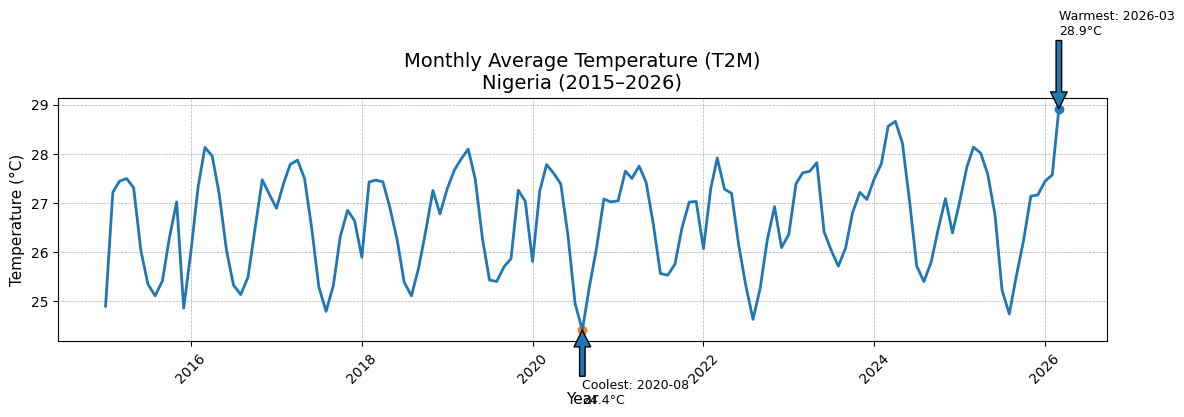

In [33]:

plt.figure(figsize=(12, 5))  # wider for time series

# Line plot
plt.plot(monthly_avg["year_month"], monthly_avg["T2M"], linewidth=2)

# Highlight warmest & coolest points
plt.scatter(warmest["year_month"], warmest["T2M"])
plt.scatter(coolest["year_month"], coolest["T2M"])

# Annotate warmest
plt.annotate(
    f"Warmest: {warmest['year_month'].strftime('%Y-%m')}\n{warmest['T2M']:.1f}°C",
    xy=(warmest["year_month"], warmest["T2M"]),
    xytext=(warmest["year_month"], warmest["T2M"] + 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Annotate coolest
plt.annotate(
    f"Coolest: {coolest['year_month'].strftime('%Y-%m')}\n{coolest['T2M']:.1f}°C",
    xy=(coolest["year_month"], coolest["T2M"]),
    xytext=(coolest["year_month"], coolest["T2M"] - 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Titles and labels
plt.title("Monthly Average Temperature (T2M)\nNigeria (2015–2026)", fontsize=14)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)

# Grid for readability
plt.grid(True, linestyle="--", linewidth=0.5)

# Improve x-axis ticks (less crowded)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## monthly total PRECTOTCORR

In [22]:
monthly_rain = df.groupby("year_month")["PRECTOTCORR"].sum().reset_index()

monthly_rain["year_month"] = monthly_rain["year_month"].dt.to_timestamp()
peak_months = monthly_rain.nlargest(2, "PRECTOTCORR")

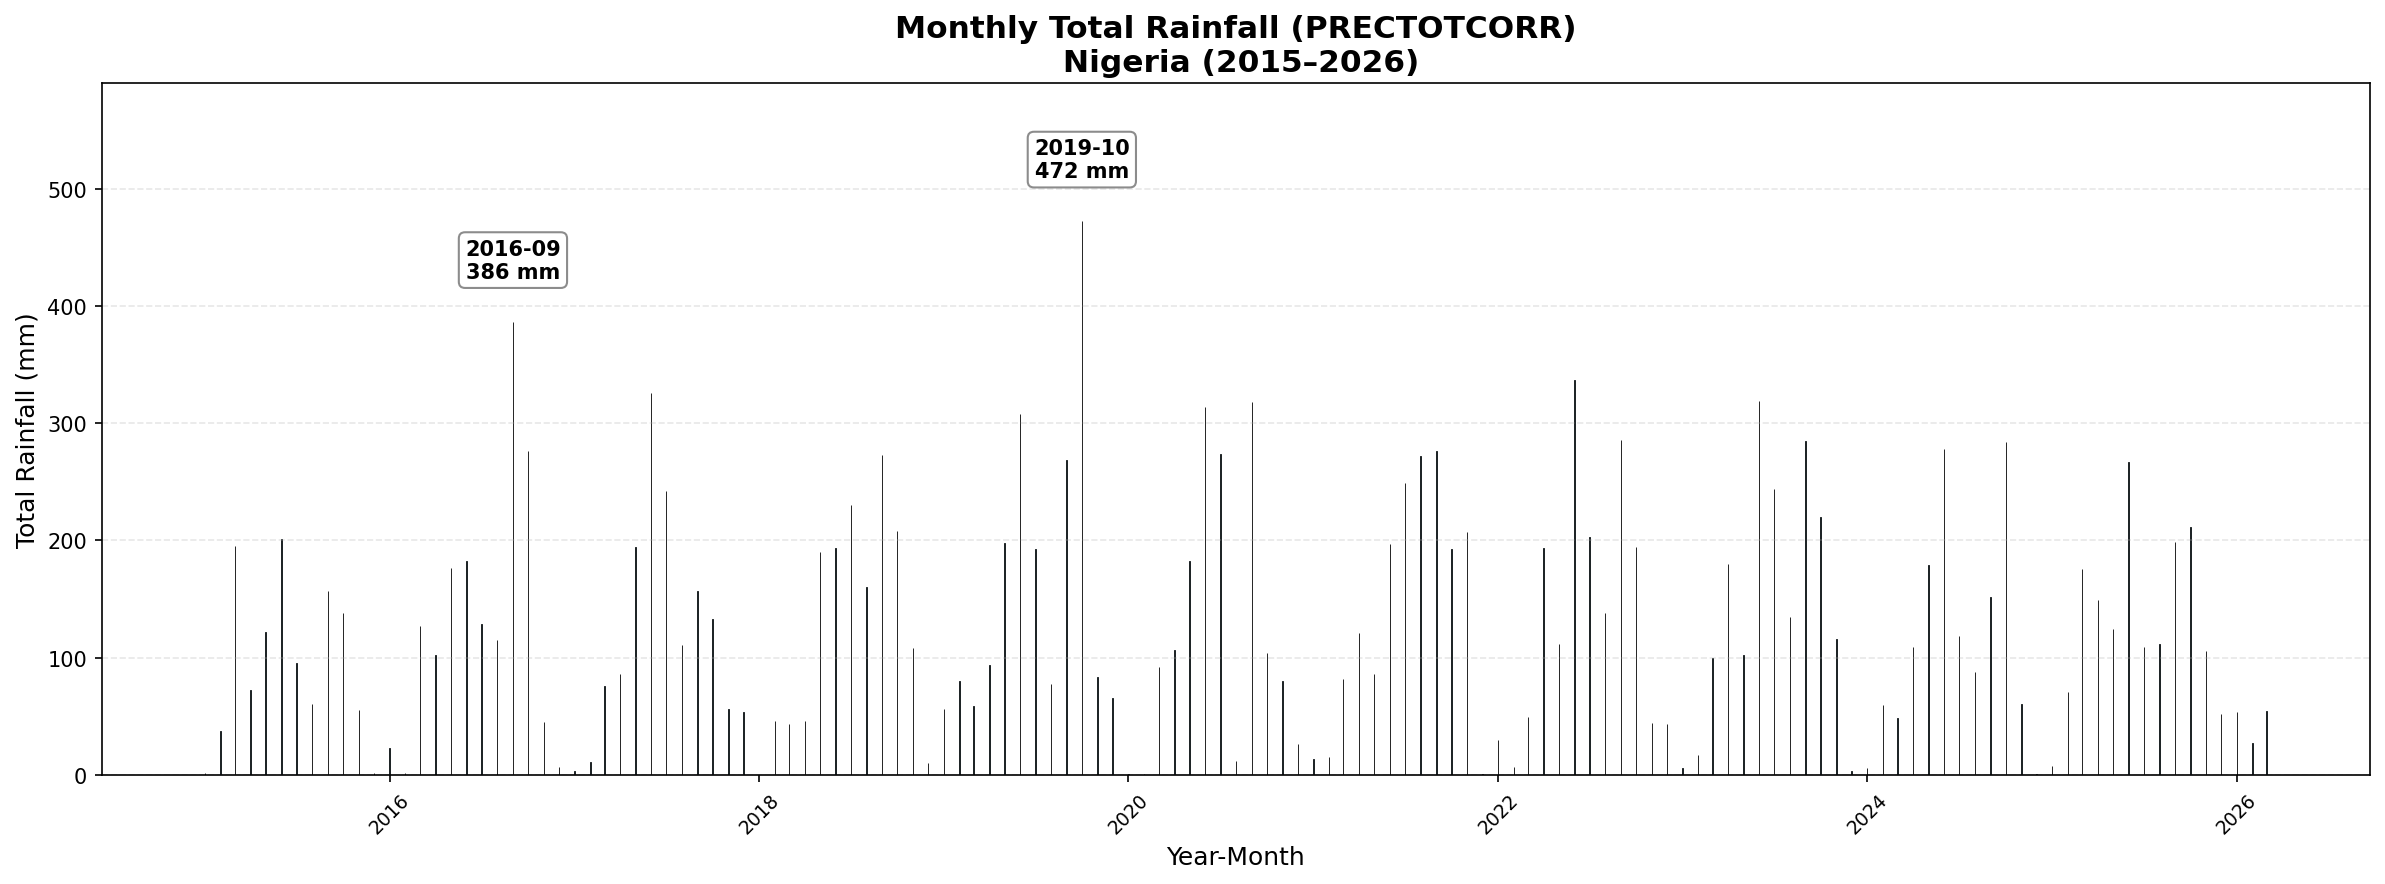

In [34]:
plt.figure(figsize=(16, 6), dpi=150)

monthly_rain_sorted = monthly_rain.sort_values("year_month")

# Base bar plot
plt.bar(
    monthly_rain_sorted["year_month"],
    monthly_rain_sorted["PRECTOTCORR"],
    color="skyblue",
    edgecolor="black",
    linewidth=0.4
)

# Peak months
peak_months = monthly_rain_sorted.nlargest(2, "PRECTOTCORR")

# Dynamic y-limit padding (IMPORTANT FIX)
y_max = monthly_rain_sorted["PRECTOTCORR"].max()
plt.ylim(0, y_max * 1.25)

# Place annotations HIGH ABOVE bars (fixed position logic)
for _, row in peak_months.iterrows():
    plt.text(
        row["year_month"],
        row["PRECTOTCORR"] + (y_max * 0.08),  # always above bar
        f"{row['year_month'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f} mm",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# Styling
plt.title("Monthly Total Rainfall (PRECTOTCORR)\n Nigeria (2015–2026)",
          fontsize=15, fontweight="bold")

plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)

plt.xticks(rotation=45, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation & Relationship Analysis

## Heatmap of correlations

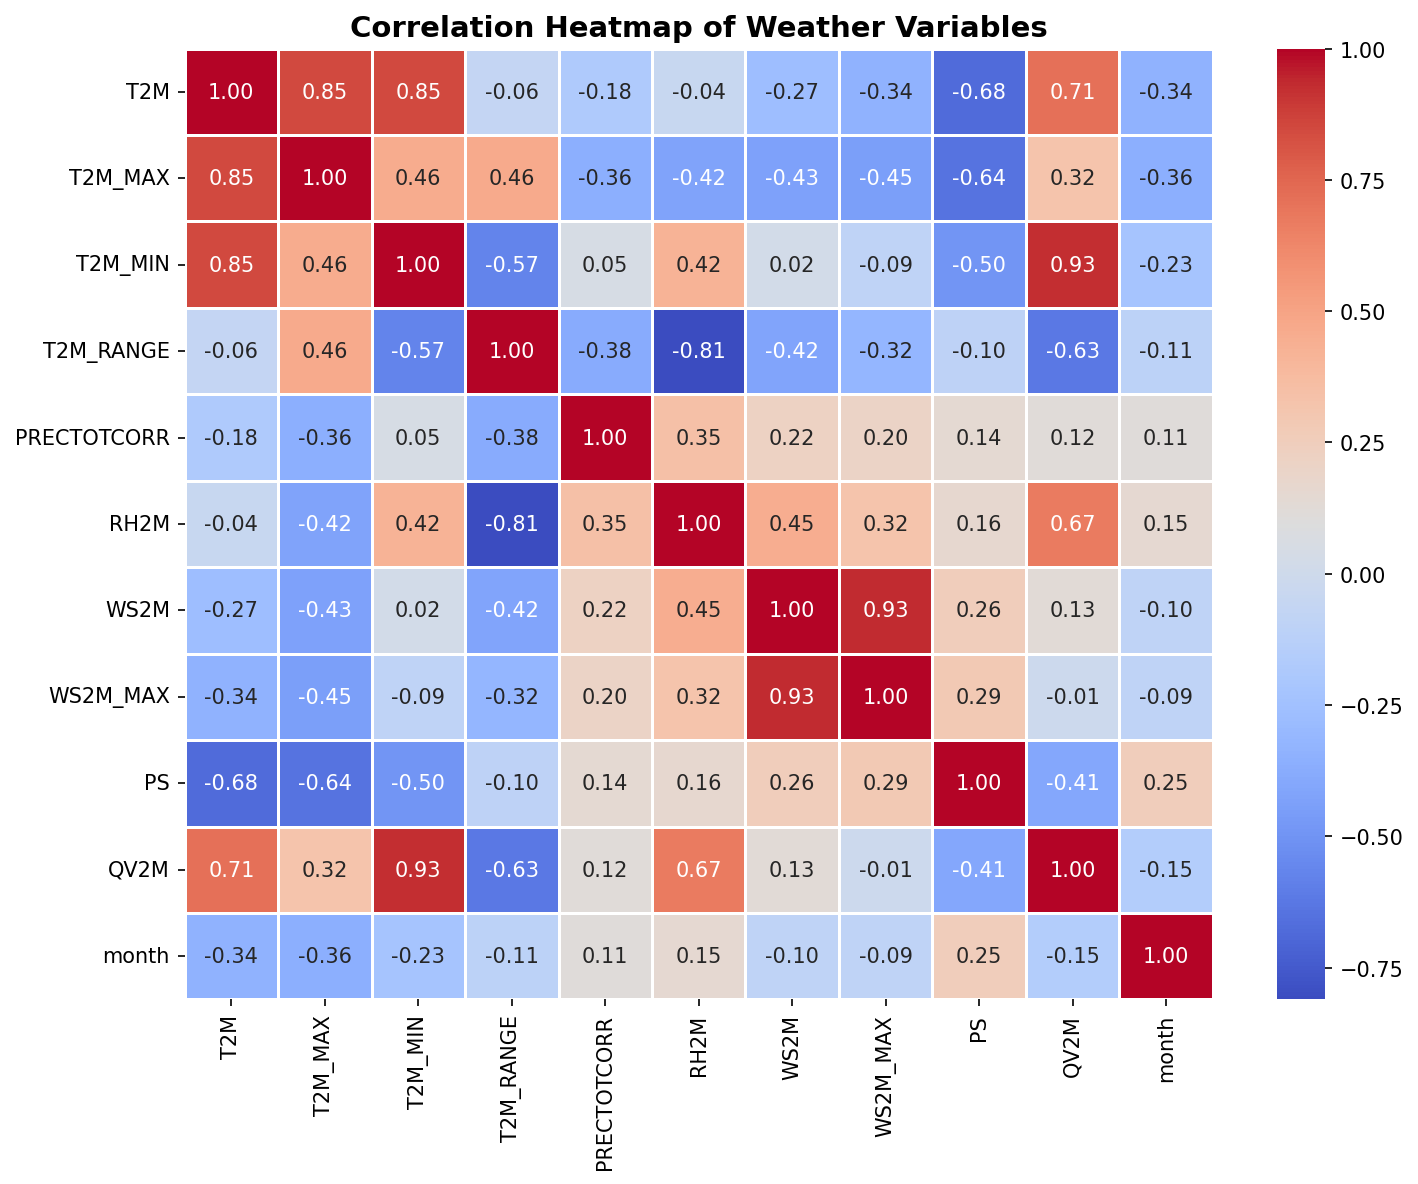

In [27]:
# Select only numeric columns and compute correlation matrix
# This measures how strongly each variable is linearly related to others
corr = df.select_dtypes(include="number").corr()
# Set figure size and resolution for better readability
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap of correlation matrix
sns.heatmap(
    corr,              # correlation values
    annot=True,        # show numerical values inside cells
    fmt=".2f",         # format numbers to 2 decimal places
    cmap="coolwarm",   # color scheme (blue = negative, red = positive)
    linewidths=0.5     # adds spacing between cells for clarity
)

# Add title to the plot
plt.title("Correlation Heatmap of Weather Variables", fontsize=14, fontweight="bold")

# Improve layout so labels don’t overlap
plt.tight_layout()

# Display the plot
plt.show()

## T2M vs RH2M (Temperature vs Humidity)

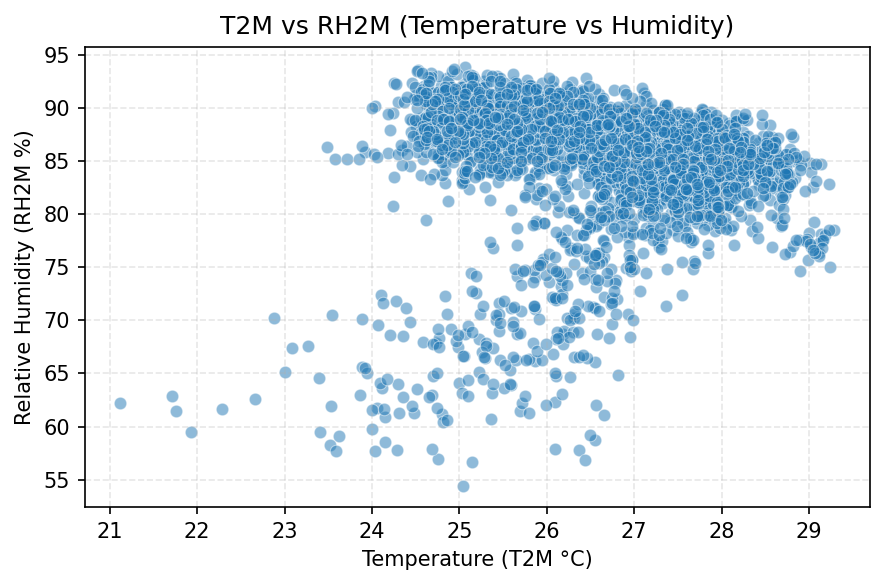

In [28]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    alpha=0.5
)

plt.title("T2M vs RH2M (Temperature vs Humidity)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)

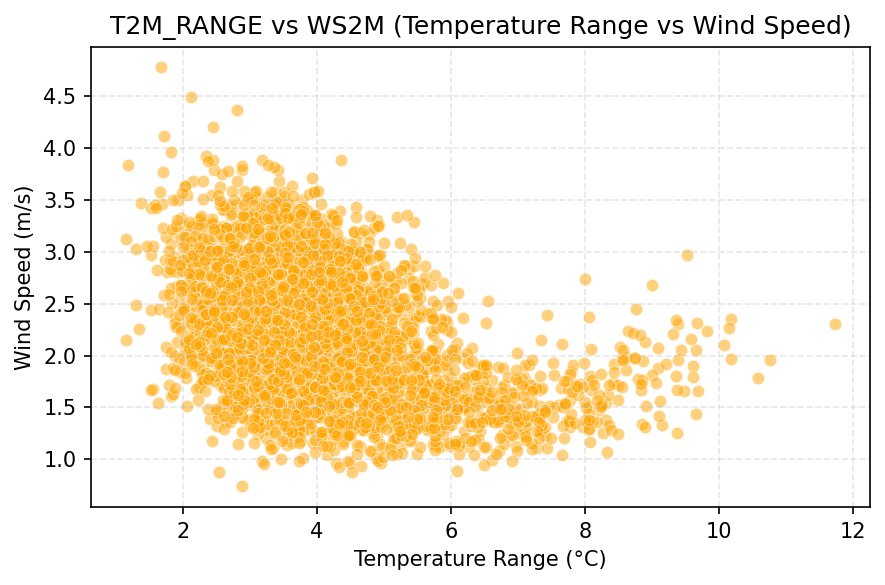

In [29]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M_RANGE",
    y="WS2M",
    alpha=0.5,
    color="orange"
)

plt.title("T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot Insights

- **T2M vs RH2M:**  
  Clear **negative correlation** is visible — as temperature increases, relative humidity generally decreases.  
  A dense cluster at high humidity (≈80–92%) suggests consistently moist conditions, while lower-humidity observations appear mostly at warmer temperatures.  
  → Temperature appears to be a **key driver of humidity variation**, with evidence of strong temperature–moisture coupling.

- **T2M_RANGE vs WS2M:**  
  A **weak inverse-to-neutral relationship** is observed with substantial dispersion.  
  Higher wind speeds tend to occur more often at lower-to-moderate temperature ranges, while large temperature ranges are mostly associated with moderate winds.  
  → Wind has **limited direct influence** on daily temperature variability, though it may play a secondary moderating role.

### Overall Insight
> The climate appears mainly driven by **temperature–humidity dynamics**, with a strong coupling between warmth and moisture conditions, while **wind plays a comparatively minor role** in explaining temperature range variability.

## Distribution Analysis

### Histogram of PRECTOTCORR

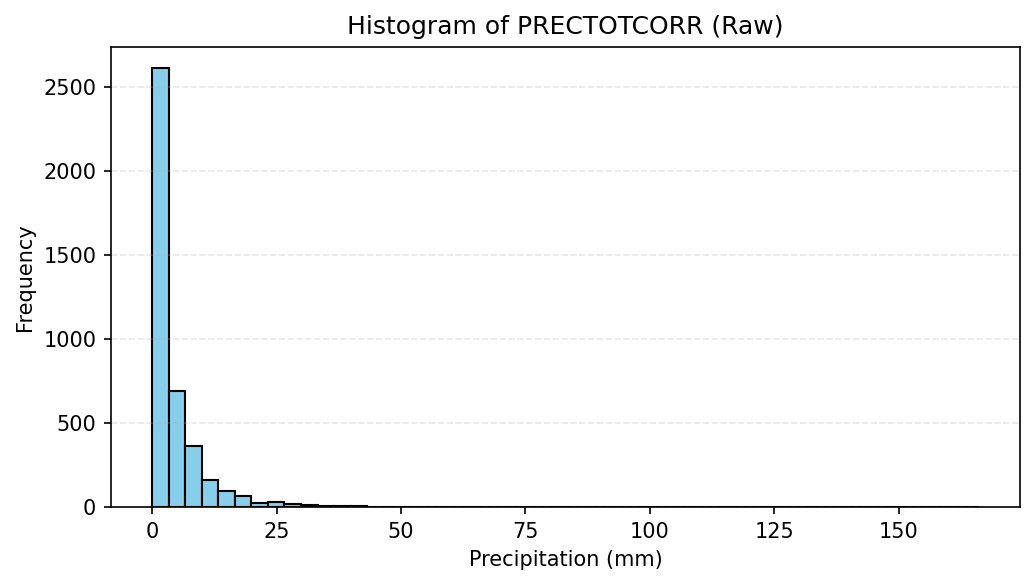

In [30]:
plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR"], bins=50, color="skyblue", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Raw)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Log-Transformed Histogram

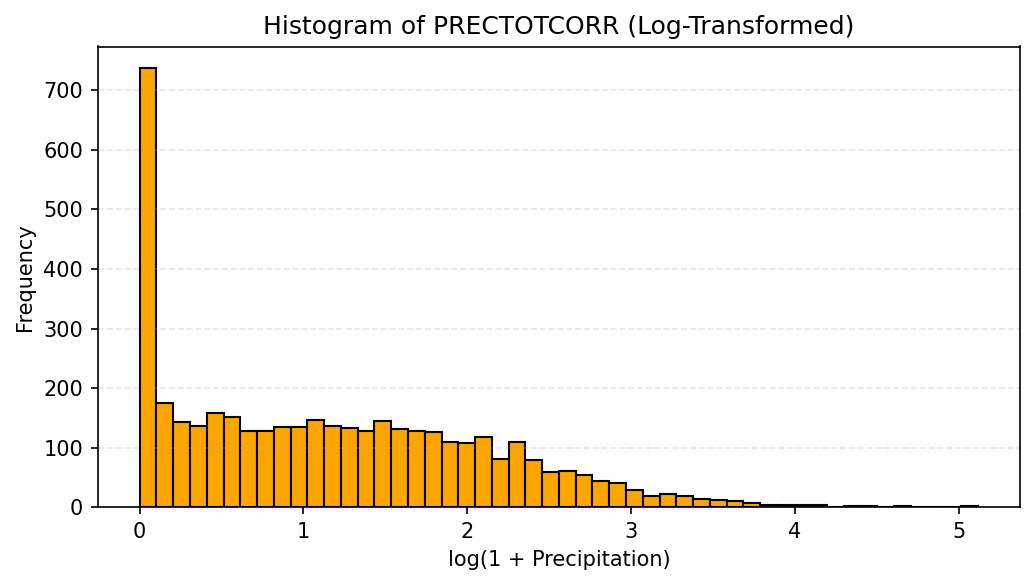

In [31]:
df["PRECTOTCORR_log"] = np.log1p(df["PRECTOTCORR"])

plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR_log"], bins=50, color="orange", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Log-Transformed)")
plt.xlabel("log(1 + Precipitation)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Distribution Analysis of PRECTOTCORR

The rainfall variable (PRECTOTCORR) shows a **strong right-skewed distribution**:

- Most observations are concentrated very close to **zero or low precipitation**, indicating many dry or low-rainfall days.
- A relatively small number of **extreme rainfall events** generate a long right tail, with some very high precipitation totals.
- This confirms rainfall is **episodic and unevenly distributed**, rather than occurring consistently over time.

After applying a logarithmic transformation:

- The distribution becomes **less skewed and more balanced**, making the underlying structure easier to observe.
- Extreme rainfall values are compressed, reducing the dominance of large storm events.
- The transformed histogram reveals variation among lower-to-moderate rainfall amounts that was masked in the raw distribution.

### 📌 Conclusion

- The original rainfall distribution is **highly skewed and non-normal**.
- A **log transformation is appropriate** for statistical modeling, correlation analysis, and visualization.
- Rainfall variability appears driven by **rare but intense precipitation events**, while most days remain relatively dry.
- This pattern reinforces earlier findings that **precipitation is the dominant source of climate variability** in the dataset.

### Bubble Chart: T2M vs RH2M (size = PRECTOTCORR)

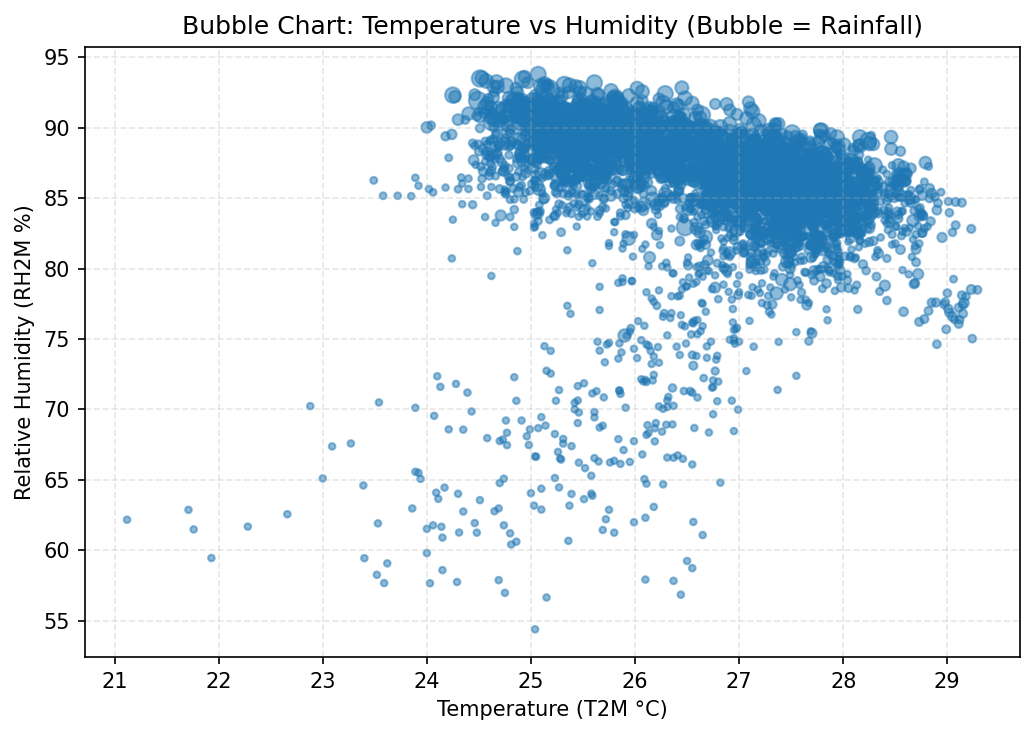

In [32]:
plt.figure(figsize=(7,5), dpi=150)

# Scale bubble size (important: rainfall can be highly skewed)
sizes = np.sqrt(df["PRECTOTCORR"] + 1) * 10  # sqrt reduces extreme dominance

plt.scatter(
    df["T2M"],          # X-axis: Temperature
    df["RH2M"],         # Y-axis: Humidity
    s=sizes,            # Bubble size: Rainfall
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Bubble Chart Analysis: Temperature, Humidity and Rainfall

The bubble chart shows a clear interaction between **temperature, humidity, and precipitation**:

- A **negative relationship** is visible between temperature and relative humidity — as temperature increases, humidity generally declines, consistent with the earlier scatter plot analysis.

- Larger bubbles (representing higher rainfall) are concentrated in **high-humidity (≈85–92%) and moderate-temperature (≈25–27°C)** regions, indicating precipitation is associated with moist atmospheric conditions.

- Warmer and relatively drier conditions tend to contain **smaller bubbles**, showing lower rainfall occurrence under those conditions.

- The clustering pattern suggests rainfall events are not randomly distributed, but occur under specific **temperature–humidity regimes**, especially where moisture availability is high.

### 📌 Conclusion

- Rainfall is strongly associated with **humid atmospheric conditions**.
- Wetter days tend to occur under **moderate temperatures**, rather than the hottest conditions.
- Humidity appears to be a **stronger driver of precipitation than temperature alone**.
- The chart reinforces earlier findings that **moisture dynamics are a major driver of climate variability** in the dataset.